In [1]:
import zipfile
import os

workspace_dir = os.getcwd()
zip_path = os.path.join(workspace_dir, "CIC-IDS-2017.zip")
extract_path = os.path.join(workspace_dir, "CIC-IDS-2017")

if os.path.isdir(extract_path):
    print(f"Data folder already exists: {extract_path}")
else:
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)
        print("Zip file extracted successfully.")
    else:
        raise FileNotFoundError(f"Zip file not found: {zip_path}. Place the ZIP in the notebook folder or update zip_path.")


Zip file extracted successfully.


In [2]:
os.listdir(extract_path)

['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 'Friday-WorkingHours-Morning.pcap_ISCX.csv',
 'Monday-WorkingHours.pcap_ISCX.csv',
 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 'Tuesday-WorkingHours.pcap_ISCX.csv',
 'Wednesday-workingHours.pcap_ISCX.csv']

In [3]:
import glob
import pandas as pd

csv_files = glob.glob("CIC-IDS-2017/*.csv")
print(csv_files)


['CIC_IDS2017\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'CIC_IDS2017\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'CIC_IDS2017\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'CIC_IDS2017\\Monday-WorkingHours.pcap_ISCX.csv', 'CIC_IDS2017\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'CIC_IDS2017\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'CIC_IDS2017\\Tuesday-WorkingHours.pcap_ISCX.csv', 'CIC_IDS2017\\Wednesday-workingHours.pcap_ISCX.csv']


In [4]:
dataframes = []

for file in csv_files:
  print(f"loadinf:{file}")
  df = pd.read_csv(file)
  print(df.shape)
  dataframes.append(df)

loadinf:CIC_IDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
(225745, 79)
loadinf:CIC_IDS2017\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
(286467, 79)
loadinf:CIC_IDS2017\Friday-WorkingHours-Morning.pcap_ISCX.csv
(191033, 79)
loadinf:CIC_IDS2017\Monday-WorkingHours.pcap_ISCX.csv
(529918, 79)
loadinf:CIC_IDS2017\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
(288602, 79)
loadinf:CIC_IDS2017\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
(170366, 79)
loadinf:CIC_IDS2017\Tuesday-WorkingHours.pcap_ISCX.csv
(445909, 79)
loadinf:CIC_IDS2017\Wednesday-workingHours.pcap_ISCX.csv
(692703, 79)


In [5]:
for i, df in enumerate(dataframes):
  print(f"\nFile{i+1}")
  print(df.columns.tolist())


File1
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' UR

In [6]:
combined_df = pd.concat(dataframes, ignore_index=True)
print(combined_df.shape)

(2830743, 79)


In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [8]:
combined_df[' Label'].value_counts()

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [9]:
null_values = combined_df.isnull().sum()
print(null_values[null_values>0])

Flow Bytes/s    1358
dtype: int64


In [10]:
import numpy as np
combined_df.replace([np.inf, -np.inf],np.nan,inplace = True)

In [11]:
null_values = combined_df.isnull().sum()
print(null_values[null_values>0])

Flow Bytes/s       2867
 Flow Packets/s    2867
dtype: int64


In [12]:
df_backup = combined_df.copy()

In [13]:
combined_df.dropna(inplace=True)

In [14]:
print(combined_df.isnull().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64


In [15]:
combined_df.duplicated().sum()

np.int64(307078)

In [16]:
combined_df.shape

(2827876, 79)

In [17]:
combined_df.drop_duplicates(inplace=True)

In [18]:
combined_df.duplicated().sum()

np.int64(0)

In [19]:
combined_df.columns = combined_df.columns.str.strip()

In [20]:
combined_df['Label'].value_counts()

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

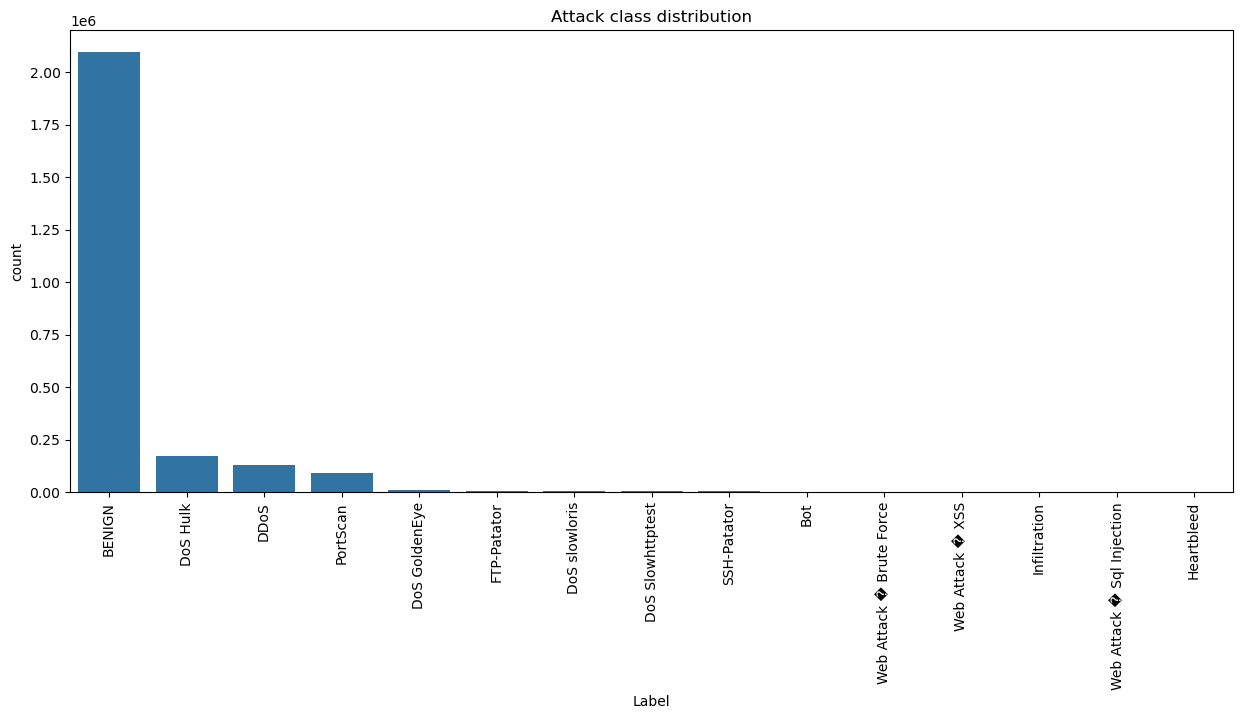

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,6))

sns.countplot(
    x = combined_df["Label"],
    order= combined_df["Label"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Attack class distribution")
plt.show()

In [22]:
combined_df.dtypes

Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object

In [ ]:
combined_df.select_dtypes(include=['object']).columns

Index(['Label'], dtype='object')

In [ ]:
X = combined_df.drop(columns=['Label'])
y = combined_df['Label']

In [25]:
numeric_features = X.columns.tolist()
numeric_features

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features)
    ]
)

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [29]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(2016638, 78)
(504160, 78)


In [30]:
!pip install tensorflow

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
print(X_train_processed.shape)

(2016638, 78)


In [33]:
model = Sequential([
    Dense(128, activation='relu',input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(len(y.unique()), activation='softmax')
])

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# NOTE: Run model training only after label encoding and data splitting are complete.
# The actual training cell is below after preprocessing and label encoding.
print("Skip this cell unless labels have been encoded and y_train is ready.")


In [37]:
print(X_train_processed.dtype)

print(y_train.dtype)

print(type(X_train_processed))

print(type(y_train))

float64
object
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [38]:
y_train.head()

670011     BENIGN
1548214    BENIGN
18529      BENIGN
1108038    BENIGN
17177      BENIGN
Name: Label, dtype: object

In [39]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
combined_df['Label'] = label_encoder.fit_transform(
    combined_df['Label']
)

In [44]:
print(combined_df['Label'].head())

print(combined_df['Label'].dtype)


0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64
int64


In [45]:
X = combined_df.drop(columns=['Label'])

y = combined_df['Label']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print(y_train.dtype)

print(y_train.head())

int64
670011     0
1548214    0
18529      0
1108038    0
17177      0
Name: Label, dtype: int64


In [48]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [49]:
import numpy as np

X_train_processed = np.asarray(X_train_processed).astype(np.float32)

X_test_processed = np.asarray(X_test_processed).astype(np.float32)

y_train = np.asarray(y_train).astype(np.int32)

y_test = np.asarray(y_test).astype(np.int32)

In [50]:
print(X_train_processed.dtype)

print(y_train.dtype)

float32
int32


In [51]:
history = model.fit(
    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=20,

    batch_size=512,

    callbacks=[early_stop]
)

Epoch 1/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9594 - loss: 0.1313 - val_accuracy: 0.9771 - val_loss: 0.0548
Epoch 2/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.9741 - loss: 0.0650 - val_accuracy: 0.9780 - val_loss: 0.0485
Epoch 3/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.9759 - loss: 0.0570 - val_accuracy: 0.9781 - val_loss: 0.0451
Epoch 4/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9773 - loss: 0.0529 - val_accuracy: 0.9818 - val_loss: 0.0411
Epoch 5/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9785 - loss: 0.0496 - val_accuracy: 0.9815 - val_loss: 0.0390
Epoch 6/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9792 - loss: 0.0480 - val_accuracy: 0.9839 - val_loss: 0.0372
Epoch 7/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9799 - loss: 0.0466 - val_accuracy: 0.9837 - val_loss: 0.0367
Epoch 8/20
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9804 - loss: 0

In [52]:
y_pred_probs = model.predict(X_test_processed)



15755/15755 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


In [53]:
y_pred = np.argmax(y_pred_probs, axis=1)

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    419012
           1       0.96      0.34      0.51       390
           2       1.00      1.00      1.00     25603
           3       0.98      0.98      0.98      2057
           4       0.98      0.99      0.98     34569
           5       0.87      0.97      0.92      1046
           6       0.96      0.96      0.96      1077
           7       0.98      0.98      0.98      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.89      0.95      0.92     18139
          11       1.00      0.90      0.95       644
          12       1.00      0.04      0.08       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    504160
   macro avg       0.71      0.61      0.62    504160
weighted avg       0.99   

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[415939      5     36     38    660    127     19     17      0      0
    2171      0      0      0      0]
 [   256    134      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [    40      0  25552      5      6      0      0      0      0      0
       0      0      0      0      0]
 [    41      0      0   2016      0      0      0      0      0      0
       0      0      0      0      0]
 [   481      0      0      0  34088      0      0      0      0      0
       0      0      0      0      0]
 [     8      0      0      0      0   1018     20      0      0      0
       0      0      0      0      0]
 [    13      0      0      0      0     21   1039      4      0      0
       0      0      0      0      0]
 [    19      0      0      0      0      0      6   1161      0      0
       0      0      0      0      0]
 [     2      0      0      0      0      0      0      0      0      0
       0      0      0      0      0]
 [     7  

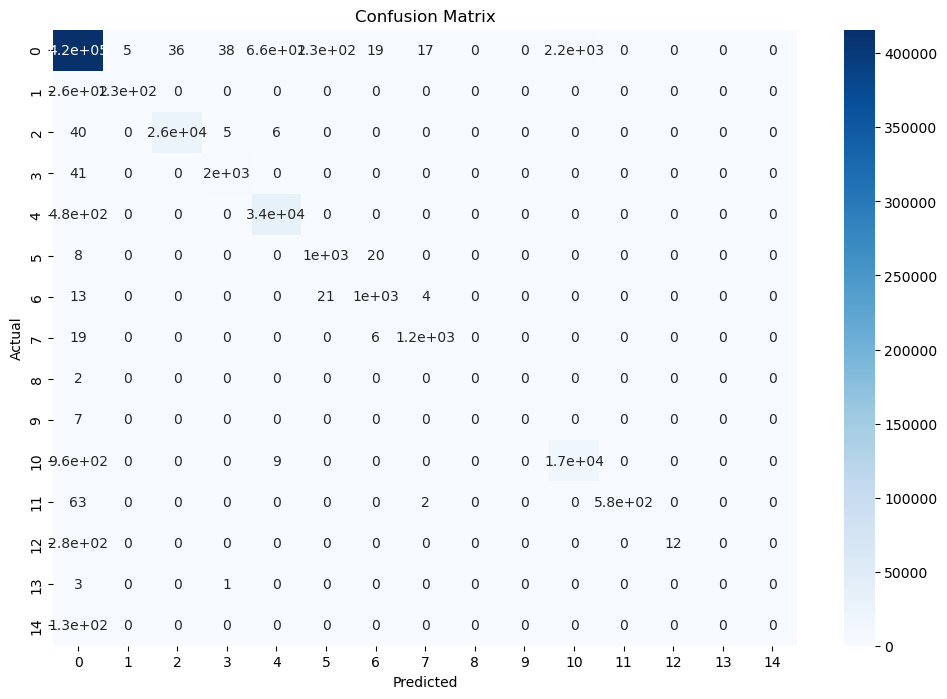

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(cm, annot=True, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

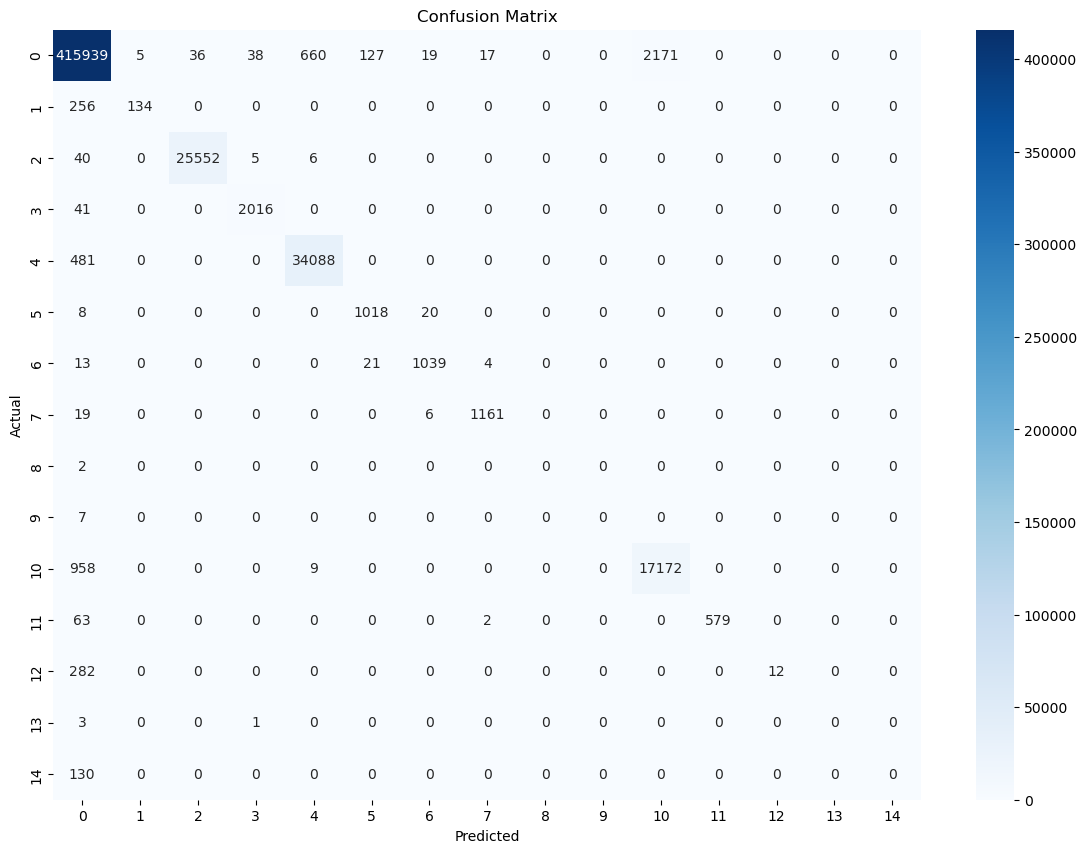

In [57]:
plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    419012
           1       0.96      0.34      0.51       390
           2       1.00      1.00      1.00     25603
           3       0.98      0.98      0.98      2057
           4       0.98      0.99      0.98     34569
           5       0.87      0.97      0.92      1046
           6       0.96      0.96      0.96      1077
           7       0.98      0.98      0.98      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.89      0.95      0.92     18139
          11       1.00      0.90      0.95       644
          12       1.00      0.04      0.08       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    504160
   macro avg       0.71      0.61      0.62    504160
weighted avg       0.99   

c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sidgu\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)
print(label_mapping)


In [60]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

In [61]:
print(label_mapping)

{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int64(13), 'Web Attack � XSS': np.int64(14)}


targeted inbalance analysis

In [62]:
class_counts = combined_df['Label'].value_counts()

print(class_counts.sort_values())

Label
8          11
13         21
9          36
14        652
12       1470
1        1948
11       3219
5        5228
6        5385
7        5931
3       10286
10      90694
2      128014
4      172846
0     2095057
Name: count, dtype: int64


In [63]:
label_mapping

{'BENIGN': np.int64(0),
 'Bot': np.int64(1),
 'DDoS': np.int64(2),
 'DoS GoldenEye': np.int64(3),
 'DoS Hulk': np.int64(4),
 'DoS Slowhttptest': np.int64(5),
 'DoS slowloris': np.int64(6),
 'FTP-Patator': np.int64(7),
 'Heartbleed': np.int64(8),
 'Infiltration': np.int64(9),
 'PortScan': np.int64(10),
 'SSH-Patator': np.int64(11),
 'Web Attack � Brute Force': np.int64(12),
 'Web Attack � Sql Injection': np.int64(13),
 'Web Attack � XSS': np.int64(14)}

In [64]:
class_counts = combined_df['Label'].value_counts()

print(class_counts.sort_values())

Label
8          11
13         21
9          36
14        652
12       1470
1        1948
11       3219
5        5228
6        5385
7        5931
3       10286
10      90694
2      128014
4      172846
0     2095057
Name: count, dtype: int64


In [65]:
minority_classes = [
    label_mapping['Web Attack � Brute Force'],
    label_mapping['SSH-Patator'],
    label_mapping['FTP-Patator'],
    label_mapping['Web Attack � XSS']
]

In [66]:
print(label_mapping.keys())

dict_keys(['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS'])


In [67]:
minority_df = combined_df[
    combined_df['Label'].isin(minority_classes)
]

In [68]:
print(minority_df['Label'].value_counts())

Label
7     5931
11    3219
12    1470
14     652
Name: count, dtype: int64


In [69]:
gan_X = minority_df.drop(columns=['Label'])

In [70]:
gan_numeric_features = gan_X.columns.tolist()

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

In [72]:
gan_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            MinMaxScaler(feature_range=(-1, 1)),
            gan_numeric_features
        )
    ]
)

In [73]:
from sklearn.pipeline import Pipeline
gan_pipeline = Pipeline([
    ('preprocessor', gan_preprocessor)
])

In [74]:
gan_data_scaled = gan_pipeline.fit_transform(gan_X)

In [75]:
import numpy as np

gan_data_scaled = np.asarray(
    gan_data_scaled
).astype(np.float32)

In [76]:
print(gan_data_scaled.shape)

print(gan_data_scaled.dtype)

(11272, 78)
float32


In [77]:
print(gan_data_scaled.shape)

(11272, 78)


In [78]:
feature_dim = gan_data_scaled.shape[1]
noise_dim = 100

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
generator = Sequential([
    Dense(128,activation='relu',input_dim = noise_dim),
    Dense(256,activation='relu'),
    Dense(512,activation='relu'),
    Dense(feature_dim,activation='tanh')
])

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
from tensorflow.keras.layers import Dropout

discrimonator = Sequential([
    Dense(512,activation='relu',input_dim=feature_dim),
    Dropout(0.3),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [81]:
from tensorflow.keras.optimizers import Adam

discrimonator.compile(
    optimizer = Adam(learning_rate = 0.0002),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
    )

In [82]:
generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 78)             │        40,014 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,550 (849.80 KB)

 Trainable params: 217,550 (849.80 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
discrimonator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,801 (800.00 KB)

 Trainable params: 204,801 (800.00 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
generator.output_shape

(None, 78)

In [85]:
print(feature_dim)
print(generator.output_shape)
print(discrimonator.output_shape)

78
(None, 78)
(None, 1)


In [86]:
discrimonator.trainable = False

In [87]:
gan = Sequential([
    generator,
    discrimonator
])

In [88]:
gan.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss = 'binary_crossentropy'
)

In [89]:
gan.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 78)             │       217,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │       204,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,351 (1.61 MB)

 Trainable params: 217,550 (849.80 KB)

 Non-trainable params: 204,801 (800.00 KB)

In [90]:
print(gan_data_scaled.shape)

(11272, 78)


In [91]:
batch_size = 64

epochs = 2000

In [92]:
import numpy as np
real_labels = np.ones((batch_size,1))
fake_labels = np.zeros((batch_size,1))

In [93]:
for epoch in range(epochs):
    # idx = np.random.randint(
    #     0,
    #     1,
    #     (batch_size,noise_dim)
    # )  invalid dimentions
    idx = np.random.randint(
    0,
    gan_data_scaled.shape[0],
    batch_size
)
    real_samples = gan_data_scaled[idx]
    
    noise = np.random.normal(
        0,
        1,
        (batch_size,noise_dim)
    )
    fake_samples = generator.predict(
        noise,
        verbose=1
    )

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━

In [94]:
print(noise.shape)
print(fake_samples.shape)
print(real_samples.shape)

(64, 100)
(64, 78)
(64, 78)


In [95]:
d_loss_real = discrimonator.train_on_batch(
    real_samples,
    real_labels
)

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [96]:
real_labels.shape

(64, 1)

In [97]:
d_loss_fake = discrimonator.train_on_batch(
    fake_samples,
    fake_labels
)

In [98]:
d_loss = 0.5*np.add(
    d_loss_real,
    d_loss_fake
)

In [99]:
g_loss  = gan.train_on_batch(
    noise,
    real_labels
)


In [100]:
gan.train_on_batch(
    noise,
    real_labels
)

0.6692098379135132

In [101]:
if epoch % 100:
    print(
        f"epoch {epoch}"
        f"D loss {d_loss[0]:.4f}"
        f"D acc: {100*d_loss[1]:.2f}% | "
        f"G loss: {g_loss:.4f}"
    )

epoch 1999D loss 0.6902D acc: 58.59% | G loss: 0.6890


In [102]:
noise = np.random.normal(
    0,
    1,
    (1000, noise_dim)
)

synthetic_samples = generator.predict(noise)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [103]:
print(synthetic_samples.shape)

(1000, 78)


In [ ]:
gan_scaler = gan_pipeline.named_steps["preprocessor"].named_transformers_["num"]
synthetic_original = gan_scaler.inverse_transform(synthetic_samples)


In [105]:
print(type(gan_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [106]:
print(type(gan_preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [111]:
print(gan_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  MinMaxScaler(feature_range=(-1,
                                                                              1)),
                                                  ['Destination Port',
                                                   'Flow Duration',
                                                   'Total Fwd Packets',
                                                   'Total Backward Packets',
                                                   'Total Length of Fwd '
                                                   'Packets',
                                                   'Total Length of Bwd '
                                                   'Packets',
                                                   'Fwd Packet Length Max',
                                                   'Fwd Packet Length Min',
                                 

In [112]:
print(gan_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num', MinMaxScaler(feature_range=(-1, 1)),
                                 ['Destination Port', 'Flow Duration',
                                  'Total Fwd Packets', 'Total Backward Packets',
                                  'Total Length of Fwd Packets',
                                  'Total Length of Bwd Packets',
                                  'Fwd Packet Length Max',
                                  'Fwd Packet Length Min',
                                  'Fwd Packet Length Mean',
                                  'Fwd Packet Length Std',
                                  'Bwd Packet Length Max',
                                  'Bwd Packet Length Min',
                                  'Bwd Packet Length Mean',
                                  'Bwd Packet Length Std', 'Flow Bytes/s',
                                  'Flow Packets/s', 'Flow IAT Mean',
                                  'Flow IAT Std', 'Flow IAT Max',

In [113]:
gan_pipeline.named_steps['preprocessor']

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [114]:
fitted_scaler = gan_pipeline.named_steps['preprocessor'].named_transformers_['num']

In [115]:
print(type(fitted_scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [117]:
synthetic_original = fitted_scaler.inverse_transform(
    synthetic_samples

)

In [118]:
synthetic_df = pd.DataFrame(
    synthetic_original,
    columns = gan_X.columns
)
synthetic_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,51.599438,83687888.0,68.091713,64.392586,20410.824219,103057.187500,781.680298,15.193176,119.510597,143.111603,...,48.212894,31.694286,0.567775,0.737568,0.491281,0.462184,0.556571,0.323617,0.569415,0.578761
1,52.949409,51734272.0,62.234791,34.067650,19635.660156,91666.125000,963.854980,17.627289,104.104362,159.559540,...,39.220264,38.491863,0.459724,0.670449,0.378618,0.396196,0.401835,0.364791,0.507451,0.514231
2,53.205769,71057800.0,68.091866,45.066307,9775.980469,101700.453125,1024.685913,12.822066,93.602325,110.320518,...,44.578712,37.238792,0.497103,0.542928,0.424233,0.686740,0.565850,0.320602,0.587419,0.497947
3,54.270176,74568720.0,89.320854,50.030903,11154.250977,119017.398438,772.446472,14.097555,93.369453,131.258850,...,48.271896,30.650042,0.578195,0.726550,0.503799,0.642621,0.482626,0.417250,0.605587,0.594757
4,53.716263,79188176.0,73.036781,46.459877,16242.801758,127143.531250,839.478027,16.961510,96.077530,141.453339,...,34.768723,28.988579,0.427916,0.719076,0.497306,0.374170,0.559912,0.506550,0.648029,0.667973


In [119]:
print(type(fitted_scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [120]:
gan_X.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,11272.000000,1.127200e+04,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,...,11272.000000,11272.000000,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0,11272.0
mean,32.397800,7.663888e+06,11.205908,14.871984,919.003460,1516.698811,187.614354,0.010468,33.105093,45.578420,...,7.097232,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,22.935642,5.589502e+06,18.461010,14.522465,3958.095685,8911.684277,278.718131,0.434797,43.193299,63.525216,...,10.384659,0.226063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,21.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,21.000000,5.224847e+06,3.000000,1.000000,14.000000,0.000000,14.000000,0.000000,7.000000,8.823894,...,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,21.000000,8.810156e+06,9.000000,15.000000,104.000000,188.000000,23.000000,0.000000,11.555556,9.899495,...,6.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,22.000000,1.101128e+07,19.000000,31.000000,2008.000000,2745.000000,640.000000,0.000000,87.304348,137.423089,...,16.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,80.000000,1.198167e+08,212.000000,114.000000,48985.000000,183700.000000,1432.000000,24.000000,241.305419,377.895735,...,101.000000,44.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
synthetic_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.202347,72057296.0,64.261475,43.843586,15216.683594,109730.914062,920.036865,16.536493,92.836861,153.249557,...,42.195160,32.669872,0.539757,0.688800,0.421257,0.466194,0.494315,0.405356,0.632273,0.528303
std,5.545724,10722853.0,17.752632,9.591345,3724.999512,13230.272461,126.703011,2.020294,21.222185,34.042866,...,8.285924,2.462265,0.097333,0.078947,0.078328,0.093275,0.093447,0.090265,0.081265,0.082965
min,34.896366,32875210.0,16.310684,17.459864,5537.715332,64391.796875,491.553558,8.049158,35.481106,52.516289,...,14.373424,24.556297,0.238679,0.398600,0.200751,0.169938,0.199064,0.111202,0.359451,0.292387
25%,49.346264,65505130.0,51.097139,37.286085,12574.506592,100542.496094,839.180725,15.155452,77.667383,130.633209,...,36.412861,31.006096,0.473058,0.640021,0.366919,0.405262,0.434232,0.341270,0.577309,0.473781
50%,53.209799,72785888.0,63.537542,43.636127,14993.259766,109408.277344,923.099915,16.646146,93.356941,151.937515,...,42.206411,32.703394,0.538302,0.691638,0.421321,0.464976,0.494361,0.400756,0.635166,0.528942
75%,57.137152,79388248.0,76.500814,50.039824,17677.126953,118443.347656,1010.248535,18.013270,106.949949,175.970963,...,47.338060,34.370728,0.608171,0.743429,0.476378,0.526277,0.559337,0.460138,0.689885,0.583943
max,67.829414,98922304.0,128.268326,77.494553,28562.169922,151728.296875,1282.833862,22.331640,149.430923,258.078186,...,69.398743,40.431293,0.807909,0.913340,0.669658,0.778260,0.796479,0.742066,0.878694,0.760432


In [124]:
print(gan_data_scaled.mean())
print(synthetic_samples.mean())

print(gan_data_scaled.std())
print(synthetic_samples.std())

-0.8268239
-0.012808812
0.45093554
0.28115058


above GAN model is fed garbage data so build new correct one

In [160]:
minority_classes = [
    label_mapping['FTP-Patator'],
    label_mapping['SSH-Patator'],
    label_mapping['Web Attack � Brute Force'],
    label_mapping['Web Attack � XSS']
]

minority_df = combined_df[
    combined_df['Label'].isin(minority_classes)
].copy()

In [161]:
gan_X = minority_df.drop(columns=['Label'])

In [162]:
zero_var_cols = gan_X.columns[
    gan_X.nunique() <= 1
]

print("Number of constant columns:", len(zero_var_cols))
print(zero_var_cols.tolist())

Number of constant columns: 23
['Bwd Packet Length Min', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Min Packet Length', 'FIN Flag Count', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']


In [163]:
gan_X_reduced = gan_X.drop(
    columns=zero_var_cols
)

print(gan_X_reduced.shape)

(11272, 55)


In [164]:
from sklearn.preprocessing import MinMaxScaler

gan_scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

gan_data_scaled = gan_scaler.fit_transform(
    gan_X_reduced
)

In [165]:
print(gan_data_scaled.shape)

(11272, 55)


In [166]:
print(gan_X_reduced.shape)
print(gan_data_scaled.shape)

(11272, 55)
(11272, 55)


In [167]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [168]:
feature_dim = gan_data_scaled.shape[1]

noise_dim = 100

print(feature_dim)

55


In [169]:
generator = Sequential([
    
    Dense(
        256,
        activation='relu',
        input_dim=noise_dim
    ),

    BatchNormalization(),

    Dense(
        512,
        activation='relu'
    ),

    BatchNormalization(),

    Dense(
        256,
        activation='relu'
    ),

    Dense(
        feature_dim,
        activation='tanh'
    )
])

generator.summary()

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 55)             │        14,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,975 (1.17 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [170]:
generator.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 55)             │        14,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,975 (1.17 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [171]:
discriminator = Sequential([

    Dense(
        256,
        activation='relu',
        input_dim=feature_dim
    ),

    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

])

discriminator.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 256)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,553 (217.00 KB)

 Trainable params: 55,553 (217.00 KB)

 Non-trainable params: 0 (0.00 B)

In [172]:
optimizer = Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [173]:
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [174]:
discriminator.trainable = False

In [175]:
gan = Sequential([
    generator,
    discriminator
])

In [176]:
gan.compile(
    loss='binary_crossentropy',
    optimizer=optimizer
)

In [177]:
gan.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 55)             │       305,975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 1)              │        55,553 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,528 (1.38 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 57,089 (223.00 KB)

In [178]:
batch_size = 64

epochs = 5000

real_labels = np.ones((batch_size, 1))

fake_labels = np.zeros((batch_size, 1))

In [179]:
idx = np.random.randint(
    0,
    1,
    (batch_size, noise_dim)
)

In [198]:
noise = np.random.normal(
    0,
    1,
    (1000, noise_dim)
)

synthetic_samples = generator.predict(
    noise,
    verbose=0
)

synthetic_original = gan_scaler.inverse_transform(
    synthetic_samples
)

synthetic_df = pd.DataFrame(
    synthetic_original,
    columns=gan_X_reduced.columns
)

In [200]:
gan_X_reduced.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward
count,11272.000000,1.127200e+04,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,...,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000,11272.000000
mean,32.397800,7.663888e+06,11.205908,14.871984,919.003460,1516.698811,187.614354,0.010468,33.105093,45.578420,...,35.797295,365.090135,11.205908,919.003460,14.871984,1516.698811,23229.245209,4840.763928,7.097232,32.000000
std,22.935642,5.589502e+06,18.461010,14.522465,3958.095685,8911.684277,278.718131,0.434797,43.193299,63.525216,...,96.884312,591.742086,18.461010,3958.095685,14.522465,8911.684277,11710.373437,10581.601240,10.384659,0.226063
min,21.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,227.000000,-1.000000,0.000000,20.000000
25%,21.000000,5.224847e+06,3.000000,1.000000,14.000000,0.000000,14.000000,0.000000,7.000000,8.823894,...,0.000000,104.000000,3.000000,14.000000,1.000000,0.000000,29200.000000,227.000000,0.000000,32.000000
50%,21.000000,8.810156e+06,9.000000,15.000000,104.000000,188.000000,23.000000,0.000000,11.555556,9.899495,...,12.533333,296.000000,9.000000,104.000000,15.000000,188.000000,29200.000000,227.000000,6.000000,32.000000
75%,22.000000,1.101128e+07,19.000000,31.000000,2008.000000,2745.000000,640.000000,0.000000,87.304348,137.423089,...,83.181818,616.000000,19.000000,2008.000000,31.000000,2745.000000,29200.000000,247.000000,16.000000,32.000000
max,80.000000,1.198167e+08,212.000000,114.000000,48985.000000,183700.000000,1432.000000,24.000000,241.305419,377.895735,...,1773.202532,6792.000000,212.000000,48985.000000,114.000000,183700.000000,29200.000000,28960.000000,101.000000,44.000000


In [201]:
synthetic_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,78.946884,64156320.0,211.735580,113.833176,7.901998,47.476105,1431.637085,0.014144,0.571358,377.031952,...,2.440173,577.679810,211.881287,48972.136719,113.957886,183673.468750,283.206299,32.929359,100.922440,20.007317
std,1.761410,16113992.0,0.529990,0.346737,16.226225,87.317024,0.930445,0.026231,0.987205,1.669937,...,7.003821,537.384460,0.308922,25.744268,0.107249,68.853294,95.049217,98.405678,0.148873,0.014866
min,61.741444,18332424.0,203.392822,108.476753,0.004380,0.005475,1415.828003,0.000019,0.000885,354.668976,...,0.004175,44.280422,206.059204,48665.183594,112.326675,182662.890625,227.096710,-0.991369,99.748138,20.000000
25%,78.768772,52402241.0,211.723072,113.823282,0.917526,7.370297,1431.689392,0.001471,0.091107,377.003487,...,0.252456,222.073490,211.891758,48970.945312,113.963470,183676.886719,236.557880,2.246786,100.924440,20.000753
50%,79.572563,64615804.0,211.905266,113.927464,3.043822,17.480674,1431.882690,0.005277,0.241583,377.564774,...,0.747712,404.866089,211.960602,48980.402344,113.988461,183692.046875,249.609329,8.719858,100.972198,20.002518
75%,79.855844,75653958.0,211.969418,113.972767,8.131823,51.240329,1431.957123,0.014215,0.640810,377.766937,...,2.115513,712.504532,211.986198,48983.596680,113.995806,183697.457031,288.982162,28.202512,100.991434,20.006763
max,79.998848,102624648.0,211.999390,113.999985,263.587708,1314.696777,1431.999878,0.255018,11.751812,377.894348,...,157.281372,4826.126465,211.999908,48985.000000,113.999969,183700.000000,1291.380981,2068.627686,100.999977,20.155947


In [202]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(gan_X_reduced[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count         1000.0        1000.000000             1000.000000
mean      64156320.0         211.735580              113.833176
std       16113992.0           0.529990                0.346737
min       18332424.0         203.392822              108.476753
25%       52402241.0         211.723072              113.823282
50%       64615804.0         211.905266 

In [199]:
gan.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 55)             │       305,975 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_9 (Sequential)       │ (None, 1)              │        55,553 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 970,408 (3.70 MB)

 Trainable params: 304,439 (1.16 MB)

 Non-trainable params: 57,089 (223.00 KB)

 Optimizer params: 608,880 (2.32 MB)

In [182]:
import numpy as np

batch_size = 64

epochs = 5000

real_labels = np.ones(
    (batch_size, 1)
)

fake_labels = np.zeros(
    (batch_size, 1)
)

In [183]:
for epoch in range(epochs):

    idx = np.random.randint(
        0,
        gan_data_scaled.shape[0],
        batch_size
    )

    real_samples = gan_data_scaled[idx]

In [184]:
print(real_samples.shape)

(64, 55)


In [185]:
noise = np.random.normal(
    0,
    1,
    (batch_size, noise_dim)
)

In [186]:
fake_samples = generator.predict(
    noise,
    verbose=0
)

In [187]:
print(real_samples.shape)
print(fake_samples.shape)

(64, 55)
(64, 55)


In [188]:
d_loss_real = discriminator.train_on_batch(
    real_samples,
    real_labels
)

c:\Users\sidgu\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [189]:
d_loss_fake = discriminator.train_on_batch(
    fake_samples,
    fake_labels
)

In [190]:
d_loss = 0.5 * np.add(
    d_loss_real,
    d_loss_fake
)

In [191]:
print(d_loss_real)
print(d_loss_fake)
print(d_loss)

[0.7790396213531494, 0.34375]
[0.6957271695137024, 0.625]
[0.7373834 0.484375 ]


In [192]:
noise = np.random.normal(
    0,
    1,
    (batch_size, noise_dim)
)

In [193]:
misleading_labels = np.ones(
    (batch_size, 1)
)

In [194]:
g_loss = gan.train_on_batch(
    noise,
    misleading_labels
)

In [ ]:
for epoch in range(epochs):

    # -------------------------
    # Train Discriminator
    # -------------------------

    idx = np.random.randint(
        0,
        gan_data_scaled.shape[0],
        batch_size
    )

    real_samples = gan_data_scaled[idx]

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    fake_samples = generator.predict(
        noise,
        verbose=0
    )

    d_loss_real = discriminator.train_on_batch(
        real_samples,
        real_labels
    )

    d_loss_fake = discriminator.train_on_batch(
        fake_samples,
        fake_labels
    )

    d_loss = 0.5 * np.add(
        d_loss_real,
        d_loss_fake
    )

    # -------------------------
    # Train Generator
    # -------------------------

    noise = np.random.normal(
        0,
        1,
        (batch_size, noise_dim)
    )

    misleading_labels = np.ones(
        (batch_size, 1)
    )

    g_loss = gan.train_on_batch(
        noise,
        misleading_labels
    )

    # -------------------------
    # Progress
    # -------------------------

    if epoch % 100 == 0:

        print(
            f"Epoch {epoch} | "
            f"D Loss: {d_loss[0]:.4f} | "
            f"D Acc: {100*d_loss[1]:.2f}% | "
            f"G Loss: {g_loss:.4f}"
        )

In [203]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(gan_X_reduced[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count         1000.0        1000.000000             1000.000000
mean      64156320.0         211.735580              113.833176
std       16113992.0           0.529990                0.346737
min       18332424.0         203.392822              108.476753
25%       52402241.0         211.723072              113.823282
50%       64615804.0         211.905266 

In [216]:
from ctgan import CTGAN

In [217]:
minority_df.shape

(11272, 79)

In [218]:
ctgan_data = minority_df.drop(
    columns=['Label']
)

In [219]:
ctgan = CTGAN(
    epochs=300
)

In [220]:
print(ctgan_data.shape)
print(ctgan_data.dtypes.value_counts())

(11272, 78)
int64      54
float64    24
Name: count, dtype: int64


In [221]:
from ctgan import CTGAN

ctgan = CTGAN(
    epochs=50,
    verbose=True
)

ctgan.fit(ctgan_data)

Gen. (-02.73) | Discrim. (-00.11): 100%|██████████| 50/50 [04:00<00:00,  4.80s/it]


In [222]:
synthetic_df = ctgan.sample(1000)

In [223]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(ctgan_data[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.000000e+03        1000.000000             1000.000000
mean    6.921822e+06          10.461000               14.486000
std     3.979122e+06           7.434497               12.990634
min    -8.611409e+06           0.000000               -2.000000
25%     4.906077e+06           4.000000                2.000000
50%     8.009878e+06           9.000000 

In [224]:
constant_cols = [
    col for col in ctgan_data.columns
    if ctgan_data[col].nunique() <= 1
]

print(len(constant_cols))

23


In [225]:
ctgan_data_reduced = ctgan_data.drop(
    columns=constant_cols
)

In [226]:
from ctgan import CTGAN

ctgan = CTGAN(
    epochs=50,
    verbose=True
)

ctgan.fit(ctgan_data)

Gen. (-02.45) | Discrim. (+00.35): 100%|██████████| 50/50 [07:09<00:00,  8.60s/it]


In [227]:
synthetic_df = ctgan.sample(1000)

In [228]:
cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]

print(ctgan_data[cols].describe())
print(synthetic_df[cols].describe())

       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.127200e+04       11272.000000            11272.000000
mean    7.663888e+06          11.205908               14.871984
std     5.589502e+06          18.461010               14.522465
min     1.000000e+00           1.000000                0.000000
25%     5.224847e+06           3.000000                1.000000
50%     8.810156e+06           9.000000               15.000000
75%     1.101128e+07          19.000000               31.000000
max     1.198167e+08         212.000000              114.000000
       Flow Duration  Total Fwd Packets  Total Backward Packets
count   1.000000e+03         1000.00000             1000.000000
mean    7.963876e+06           11.15000               15.039000
std     4.683857e+06           12.15785               13.542041
min    -6.383153e+06            0.00000               -3.000000
25%     5.755940e+06            4.00000                2.000000
50%     8.848900e+06            9.00000 

In [ ]:
# synthetic_df['Flow Duration'] = (
#     synthetic_df['Flow Duration']
#     .clip(lower=0)
# )

# synthetic_df['Total Fwd Packets'] = (
#     synthetic_df['Total Fwd Packets']
#     .clip(lower=0)
#     .round()
# )

# synthetic_df['Total Backward Packets'] = (
#     synthetic_df['Total Backward Packets']
#     .clip(lower=0)
#     .round()
# )

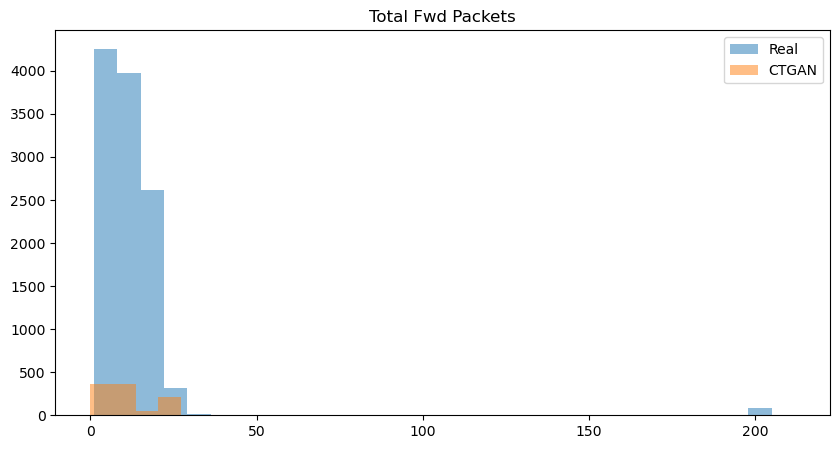

In [230]:
import matplotlib.pyplot as plt

feature = 'Total Fwd Packets'

plt.figure(figsize=(10,5))

plt.hist(
    ctgan_data[feature],
    bins=30,
    alpha=0.5,
    label='Real'
)

plt.hist(
    synthetic_df[feature],
    bins=30,
    alpha=0.5,
    label='CTGAN'
)

plt.legend()
plt.title(feature)
plt.show()

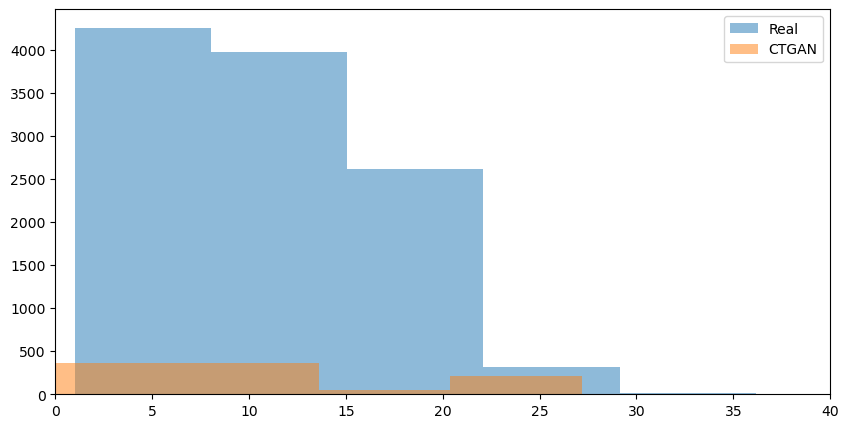

In [231]:
plt.figure(figsize=(10,5))

plt.hist(
    ctgan_data['Total Fwd Packets'],
    bins=30,
    alpha=0.5,
    label='Real'
)

plt.hist(
    synthetic_df['Total Fwd Packets'],
    bins=30,
    alpha=0.5,
    label='CTGAN'
)

plt.xlim(0, 40)

plt.legend()
plt.show()

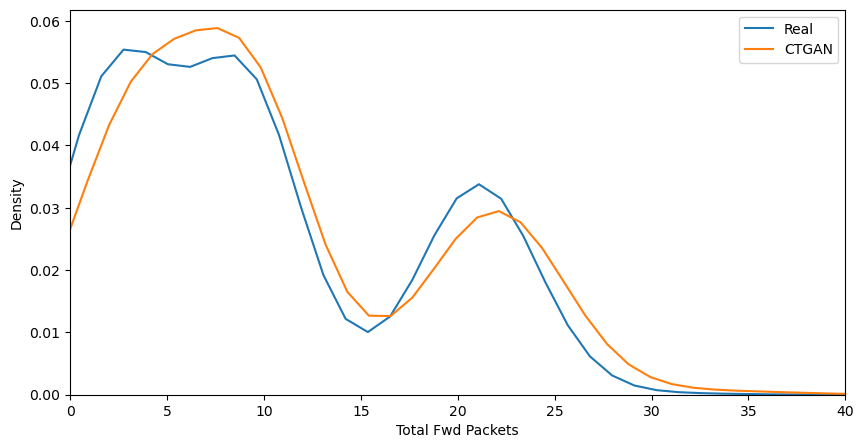

In [232]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.kdeplot(
    ctgan_data['Total Fwd Packets'],
    label='Real'
)

sns.kdeplot(
    synthetic_df['Total Fwd Packets'],
    label='CTGAN'
)

plt.xlim(0,40)

plt.legend()
plt.show()